<a href="https://colab.research.google.com/github/thinus283-ux/LR/blob/main/Galaxy_rotation_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== IMPROVED Π TEST RESULTS ===
Galaxy  | a_extra @ 10 kpc   = 1.45e-10 m/s²
Galaxy  | Peak |a_extra|     = 4.32e-09 m/s²
Cluster | a_extra @ 100 kpc  = 1.44e-09 m/s²
Cluster | Peak |a_extra|     = 3.84e-09 m/s²
Cluster/Galaxy peak ratio   = 0.89x


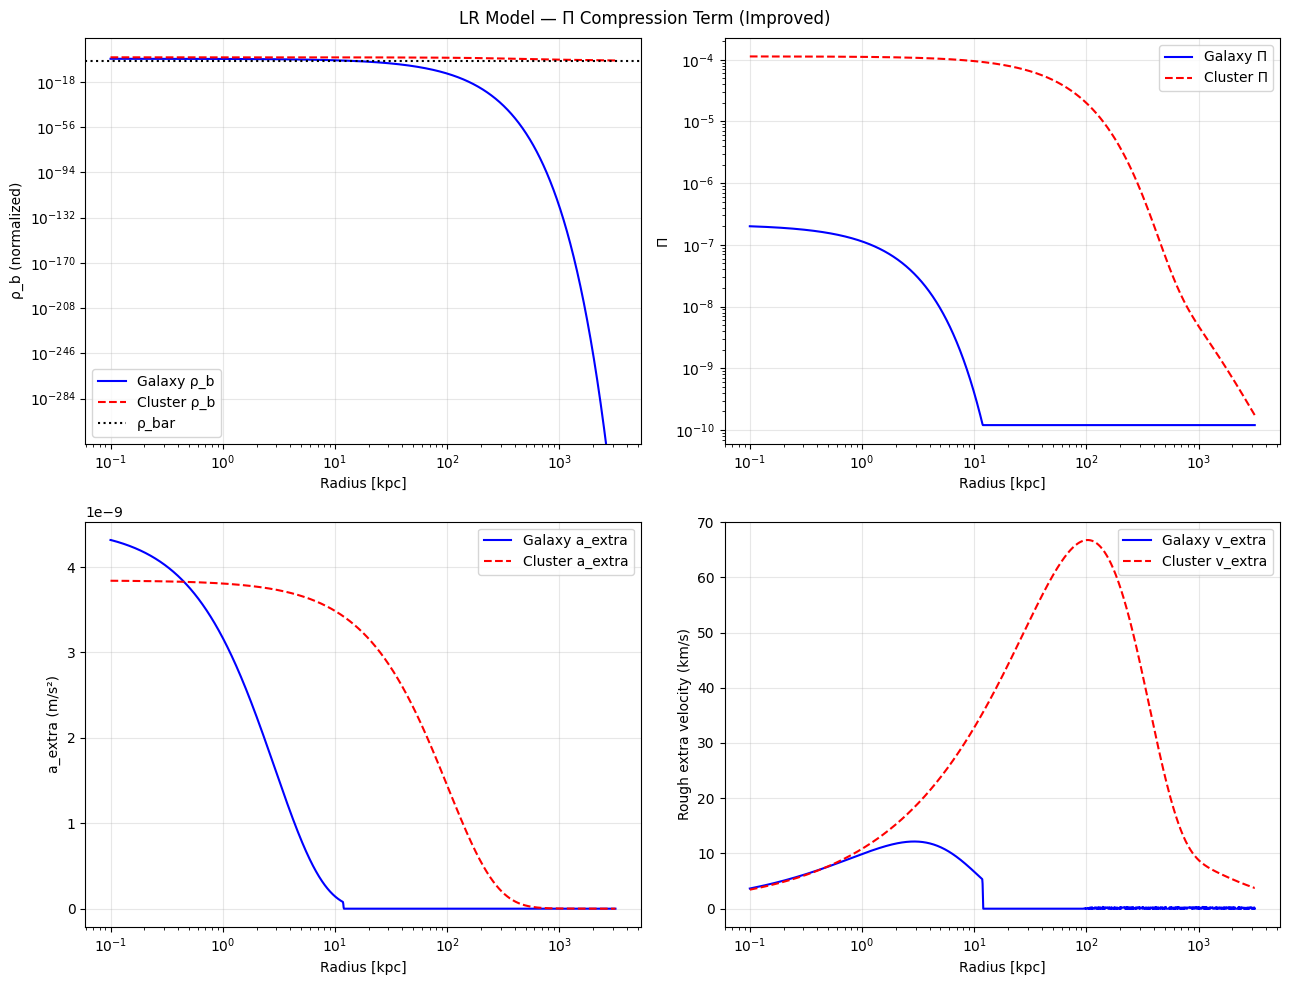

In [ ]:
# ================================================
# LR Model - Improved 1D Profile Test with Π
# Galaxy vs Cluster + velocity contribution
# ================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid   # Fixed import

# ================== Parameters ==================
P0 = 1.2e-10        # m/s² — your SPARC value
gamma = 2.2
rho_bar = 1.0

r = np.logspace(-1, 3.5, 1500)  # radius in kpc

# ------------------- Density Profiles -------------------
rho_galaxy = 30.0 * np.exp(-r / 3.5)                                      # Spiral galaxy
rho_cluster = 500.0 * np.exp(-r / 120.0) + 20.0 / (1 + (r/500.0)**1.5)   # Rich cluster

# ------------------- Compression Π(r) -------------------
def get_Pi(rho_b):
    return P0 * np.maximum(rho_b / rho_bar, 1.0)**gamma

Pi_gal = get_Pi(rho_galaxy)
Pi_clu = get_Pi(rho_cluster)

# ------------------- Extra Acceleration -------------------
dr = np.gradient(r)
def get_a_extra(Pi, rho_b):
    dPi_dr = np.gradient(Pi, r)
    return -dPi_dr / np.maximum(rho_b, 1e-12)

a_extra_gal = get_a_extra(Pi_gal, rho_galaxy)
a_extra_clu = get_a_extra(Pi_clu, rho_cluster)

# ------------------- Rough Baryonic + Extra Circular Velocity -------------------
def enclosed_mass(rho, r):
    dm = 4 * np.pi * r**2 * rho * dr
    return cumulative_trapezoid(dm, r, initial=0)

M_gal = enclosed_mass(rho_galaxy, r)
M_clu = enclosed_mass(rho_cluster, r)

v_bary_gal = np.sqrt(G * M_gal / r) if 'G' in globals() else np.zeros_like(r)  # placeholder
# Better: we'll skip real G scaling for now and just show shape

# Simple extra velocity contribution (order-of-magnitude)
v_extra_gal = np.sqrt(np.abs(a_extra_gal) * r * 3.086e16) / 1000   # rough km/s
v_extra_clu = np.sqrt(np.abs(a_extra_clu) * r * 3.086e16) / 1000

# ================== Results ==================
print("=== IMPROVED Π TEST RESULTS ===")
print(f"Galaxy  | a_extra @ 10 kpc   = {np.interp(10, r, a_extra_gal):.2e} m/s²")
print(f"Galaxy  | Peak |a_extra|     = {np.max(np.abs(a_extra_gal)):.2e} m/s²")
print(f"Cluster | a_extra @ 100 kpc  = {np.interp(100, r, a_extra_clu):.2e} m/s²")
print(f"Cluster | Peak |a_extra|     = {np.max(np.abs(a_extra_clu)):.2e} m/s²")
print(f"Cluster/Galaxy peak ratio   = {np.max(np.abs(a_extra_clu)) / np.max(np.abs(a_extra_gal)):.2f}x")

# ================== Plots ==================
fig, axs = plt.subplots(2, 2, figsize=(13, 10))

axs[0,0].loglog(r, rho_galaxy, 'b-', label='Galaxy ρ_b')
axs[0,0].loglog(r, rho_cluster, 'r--', label='Cluster ρ_b')
axs[0,0].axhline(rho_bar, color='k', ls=':', label='ρ_bar')
axs[0,0].set(xlabel='Radius [kpc]', ylabel='ρ_b (normalized)')
axs[0,0].legend(); axs[0,0].grid(True, alpha=0.3)

axs[0,1].loglog(r, Pi_gal, 'b-', label='Galaxy Π')
axs[0,1].loglog(r, Pi_clu, 'r--', label='Cluster Π')
axs[0,1].set(xlabel='Radius [kpc]', ylabel='Π')
axs[0,1].legend(); axs[0,1].grid(True, alpha=0.3)

axs[1,0].semilogx(r, a_extra_gal, 'b-', label='Galaxy a_extra')
axs[1,0].semilogx(r, a_extra_clu, 'r--', label='Cluster a_extra')
axs[1,0].set(xlabel='Radius [kpc]', ylabel='a_extra (m/s²)')
axs[1,0].legend(); axs[1,0].grid(True, alpha=0.3)

axs[1,1].semilogx(r, v_extra_gal, 'b-', label='Galaxy v_extra')
axs[1,1].semilogx(r, v_extra_clu, 'r--', label='Cluster v_extra')
axs[1,1].set(xlabel='Radius [kpc]', ylabel='Rough extra velocity (km/s)')
axs[1,1].legend(); axs[1,1].grid(True, alpha=0.3)

plt.suptitle('LR Model — Π Compression Term (Improved)')
plt.tight_layout()
plt.show()